# Body-count prediction — EDA, preprocessing, and modelling
This notebook loads `synthetic_bodycount_dataset.csv`, performs EDA, builds a preprocessing pipeline, trains a LightGBM model on `log1p(body_count)`, evaluates with CV, and saves the final model.

In [17]:
%pip install -q pandas numpy scikit-learn lightgbm catboost xgboost optuna shap matplotlib seaborn category_encoders joblib

Note: you may need to restart the kernel to use updated packages.


In [18]:
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split, KFold
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler, FunctionTransformer, OneHotEncoder
from category_encoders import TargetEncoder
from lightgbm import LGBMRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error
from sklearn.inspection import permutation_importance
import joblib
import warnings
warnings.filterwarnings('ignore')
sns.set(style='whitegrid')

In [19]:
# Load data
DATA_PATH = 'synthetic_bodycount_dataset.csv'
df = pd.read_csv(DATA_PATH)
print('Rows, cols:', df.shape)
df.head()

Rows, cols: (15000, 24)


,followers,following,is_public,post_count,story_freq,city_tier,party_freq,cafe_freq,travel_freq,gym_freq,...,mommy_issues,therapy_issues,situationship_lore,soft_launch_history,astrology_phase,friend_circle_size,spotify_vibe,random_chaos,bio_type,body_count
0,7320,578,0,82,3,2,5,2,4,3,...,1,0,0,0,0,2,3,0.406655,0,8
1,910,2030,0,576,0,2,4,3,1,5,...,0,0,0,0,1,1,1,0.745965,1,4
2,5440,2219,0,451,3,1,3,1,3,1,...,1,1,0,0,1,2,3,0.318891,0,10
3,13468,2989,1,2,4,1,3,4,3,3,...,1,1,1,1,0,2,1,0.506059,0,19
4,5241,2107,0,455,0,1,0,0,2,5,...,0,1,0,0,1,1,3,0.239330,1,13


In [20]:
# Quick summaries
display(df.info())
display(df.describe(include='all').T)
print('Missing values per column:')
display(df.isnull().sum().sort_values(ascending=False).head(30))
print('Target distribution (value counts):')
display(df['body_count'].value_counts().sort_index().head(30))

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 15000 entries, 0 to 14999
Data columns (total 24 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   followers            15000 non-null  int64  
 1   following            15000 non-null  int64  
 2   is_public            15000 non-null  int64  
 3   post_count           15000 non-null  int64  
 4   story_freq           15000 non-null  int64  
 5   city_tier            15000 non-null  int64  
 6   party_freq           15000 non-null  int64  
 7   cafe_freq            15000 non-null  int64  
 8   travel_freq          15000 non-null  int64  
 9   gym_freq             15000 non-null  int64  
 10  is_influencer        15000 non-null  int64  
 11  dm_open              15000 non-null  int64  
 12  toxic_ex             15000 non-null  int64  
 13  daddy_issues         15000 non-null  int64  
 14  mommy_issues         15000 non-null  int64  
 15  therapy_issues       15000 non-null 

None

,count,mean,std,min,25%,50%,75%,max
followers,15000.0,7492.996800,4312.761924,51.000000,3768.00000,7441.00000,11252.500000,14999.000000
following,15000.0,1530.658133,845.056343,50.000000,809.00000,1535.50000,2253.000000,2999.000000
is_public,15000.0,0.492067,0.499954,0.000000,0.00000,0.00000,1.000000,1.000000
post_count,15000.0,396.378467,231.311829,0.000000,196.00000,395.00000,594.250000,799.000000
story_freq,15000.0,2.511600,1.713416,0.000000,1.00000,3.00000,4.000000,5.000000
city_tier,15000.0,1.849200,0.791350,1.000000,1.00000,2.00000,2.000000,3.000000
party_freq,15000.0,2.489133,1.708082,0.000000,1.00000,2.00000,4.000000,5.000000
cafe_freq,15000.0,2.493800,1.720007,0.000000,1.00000,2.00000,4.000000,5.000000
travel_freq,15000.0,2.524667,1.695990,0.000000,1.00000,3.00000,4.000000,5.000000
gym_freq,15000.0,2.489467,1.710190,0.000000,1.00000,2.00000,4.000000,5.000000


Missing values per column:


followers              0
following              0
is_public              0
post_count             0
story_freq             0
city_tier              0
party_freq             0
cafe_freq              0
travel_freq            0
gym_freq               0
is_influencer          0
dm_open                0
toxic_ex               0
daddy_issues           0
mommy_issues           0
therapy_issues         0
situationship_lore     0
soft_launch_history    0
astrology_phase        0
friend_circle_size     0
spotify_vibe           0
random_chaos           0
bio_type               0
body_count             0
dtype: int64

Target distribution (value counts):


body_count
2        5
3        3
4       23
5       49
6       99
7      190
8      324
9      492
10     708
11    1055
12    1244
13    1488
14    1674
15    1592
16    1541
17    1318
18    1089
19     817
20    1289
Name: count, dtype: int64

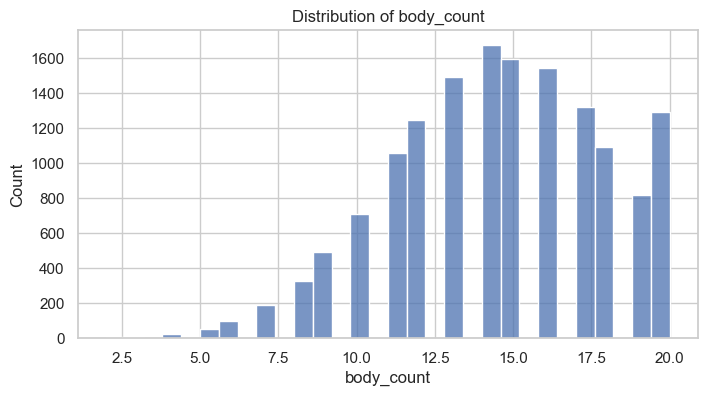

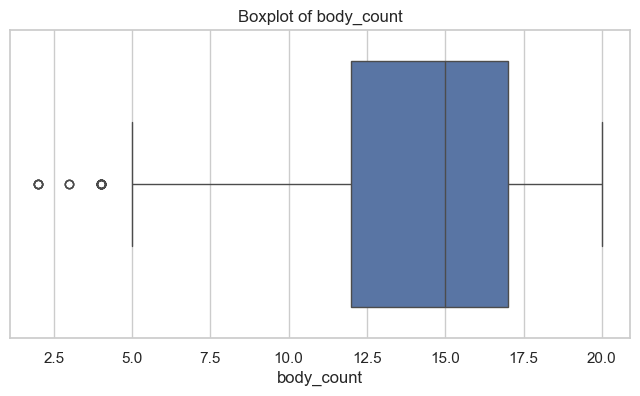

In [21]:
# Target histogram and basic plot
plt.figure(figsize=(8,4))
sns.histplot(df['body_count'], bins=30, kde=False)
plt.title('Distribution of body_count')
plt.show()
plt.figure(figsize=(8,4))
sns.boxplot(x=df['body_count'])
plt.title('Boxplot of body_count')
plt.show()

In [22]:
# Identify categorical (low-cardinality) vs numeric features automatically
TARGET = 'body_count'
all_features = [c for c in df.columns if c != TARGET]
low_cardinality = [c for c in all_features if df[c].nunique() <= 10]
high_cardinality = [c for c in all_features if df[c].nunique() > 10]
print('Low-cardinality (treat as categorical):', low_cardinality)
print('High-cardinality (treat as numeric):', [c for c in high_cardinality if c not in low_cardinality][:20])

Low-cardinality (treat as categorical): ['is_public', 'story_freq', 'city_tier', 'party_freq', 'cafe_freq', 'travel_freq', 'gym_freq', 'is_influencer', 'dm_open', 'toxic_ex', 'daddy_issues', 'mommy_issues', 'therapy_issues', 'situationship_lore', 'soft_launch_history', 'astrology_phase', 'friend_circle_size', 'spotify_vibe', 'bio_type']
High-cardinality (treat as numeric): ['followers', 'following', 'post_count', 'random_chaos']


## Preprocessing pipeline
- Numeric features: median imputation, log1p transform, standard scaling
- Categorical (low-card): median impute with constant and `TargetEncoder` (fits with y inside the pipeline)
- Target: train on `log1p(body_count)` and invert predictions with `expm1` for evaluation.

In [23]:
# Build preprocessing pipelines
categorical_cols = low_cardinality
numeric_cols = [c for c in all_features if c not in categorical_cols]
print('Numeric cols:', numeric_cols[:20])
print('Categorical cols:', categorical_cols)
num_pipe = Pipeline([
    ('impute', SimpleImputer(strategy='median')),
    ('log', FunctionTransformer(np.log1p, validate=False)),
    ('scale', StandardScaler())
])
cat_pipe = Pipeline([
    ('impute', SimpleImputer(strategy='most_frequent')),
    ('target', TargetEncoder()),
])
preproc = ColumnTransformer([
    ('num', num_pipe, numeric_cols),
    ('cat', cat_pipe, categorical_cols)
])

Numeric cols: ['followers', 'following', 'post_count', 'random_chaos']
Categorical cols: ['is_public', 'story_freq', 'city_tier', 'party_freq', 'cafe_freq', 'travel_freq', 'gym_freq', 'is_influencer', 'dm_open', 'toxic_ex', 'daddy_issues', 'mommy_issues', 'therapy_issues', 'situationship_lore', 'soft_launch_history', 'astrology_phase', 'friend_circle_size', 'spotify_vibe', 'bio_type']


In [24]:
# Prepare data and hold-out split
X = df.drop(TARGET, axis=1)
y = df[TARGET].astype(int)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.15, random_state=42)
print('Train size:', X_train.shape, 'Test size:', X_test.shape)

Train size: (12750, 23) Test size: (2250, 23)


In [25]:
# Model pipeline (train on log1p target)
model = LGBMRegressor(objective='regression', n_estimators=2000, learning_rate=0.05, random_state=42)
pipeline = Pipeline([('preproc', preproc), ('model', model)])
# Cross-validation on training set
kf = KFold(n_splits=5, shuffle=True, random_state=42)
maes = []
rmses = []
from sklearn.base import clone
for fold, (tr_idx, val_idx) in enumerate(kf.split(X_train), 1):
    X_tr, X_val = X_train.iloc[tr_idx], X_train.iloc[val_idx]
    y_tr, y_val = y_train.iloc[tr_idx], y_train.iloc[val_idx]
    y_tr_log = np.log1p(y_tr)
    p = clone(pipeline)
    p.fit(X_tr, y_tr_log)
    y_pred_log = p.predict(X_val)
    y_pred = np.expm1(y_pred_log)
    mae = mean_absolute_error(y_val, y_pred)
    rmse = np.sqrt(mean_squared_error(y_val, y_pred))
    print(f'Fold {fold}: MAE={mae:.4f}, RMSE={rmse:.4f}')
    maes.append(mae); rmses.append(rmse)
print(f'CV mean MAE={np.mean(maes):.4f} ± {np.std(maes):.4f}')
print(f'CV mean RMSE={np.mean(rmses):.4f} ± {np.std(rmses):.4f}')

[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.000241 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 1085
[LightGBM] [Info] Number of data points in the train set: 10200, number of used features: 23
[LightGBM] [Info] Start training from score 2.716300
Fold 1: MAE=1.0244, RMSE=1.2051
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.000349 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 1085
[LightGBM] [Info] Number of data points in the train set: 10200, number of used features: 23
[LightGBM] [Info] Start training from score 2.714893
Fold 2: MAE=1.0415, RMSE=1.2143
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.000281 seconds.
You can set `force_r

In [26]:
# Fit on full training set and evaluate on hold-out test set
pipeline.fit(X_train, np.log1p(y_train))
y_test_pred = np.expm1(pipeline.predict(X_test))
test_mae = mean_absolute_error(y_test, y_test_pred)
test_rmse = np.sqrt(mean_squared_error(y_test, y_test_pred))
print(f'Test MAE={test_mae:.4f}, Test RMSE={test_rmse:.4f}')

[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.000261 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 1085
[LightGBM] [Info] Number of data points in the train set: 12750, number of used features: 23
[LightGBM] [Info] Start training from score 2.714563
Test MAE=0.9895, Test RMSE=1.1690


In [27]:
# Permutation importance (slower) to get feature importance on pipeline
res = permutation_importance(pipeline, X_test, y_test, n_repeats=8, random_state=42, scoring='neg_mean_absolute_error')
feature_names = numeric_cols + categorical_cols
imp_df = pd.DataFrame({'feature': feature_names, 'importance_mean': res.importances_mean, 'importance_std': res.importances_std})
imp_df = imp_df.sort_values('importance_mean', ascending=False)
imp_df.head(20)

,feature,importance_mean,importance_std
17,situationship_lore,0.000451,0.000453
7,party_freq,0.000149,0.000136
18,soft_launch_history,0.000070,0.000095
2,post_count,0.000062,0.000517
14,daddy_issues,0.000049,0.000097
9,travel_freq,0.000017,0.000197
8,cafe_freq,0.000016,0.000062
15,mommy_issues,-0.000021,0.000066
21,spotify_vibe,-0.000044,0.000199
4,is_public,-0.000087,0.000336


In [28]:
# Save pipeline
os.makedirs('models', exist_ok=True)
joblib.dump(pipeline, 'models/lgbm_bodycount_pipeline.joblib')
print('Saved model to models/lgbm_bodycount_pipeline.joblib')

Saved model to models/lgbm_bodycount_pipeline.joblib


## Notes & next steps
- Try `CatBoostRegressor` (handles categoricals natively) and LightGBM with `objective='poisson'` or Tweedie if counts distribution suggests it.
- If many zeros, consider a two-stage model (classify zero vs non-zero, then regress positives).
- Use `Optuna` to tune hyperparameters and consider stacking/ensembling for best accuracy.